 Predicting GDP per Capita Using Macroeconomic Indicators

Objective:
Investigate whether macroeconomic and development indicators can predict
cross-country GDP per capita using World Bank WDI data (2021).

Questions:
- Which indicators are most strongly associated with GDP?
- Are relationships linear or nonlinear?
- Which machine learning model performs better?

In [6]:
import pandas as pd

In [7]:
import chardet

df = pd.read_csv("../data/raw.csv")

In [8]:
df.replace("..", pd.NA, inplace=True)

,Country Name,Country Code,2021 [YR2021] - Gini index [SI.POV.GINI],2021 [YR2021] - GDP per capita (current US$) [NY.GDP.PCAP.CD],"2021 [YR2021] - Literacy rate, adult total (% of people ages 15 and above) [SE.ADT.LITR.ZS]","2021 [YR2021] - Life expectancy at birth, total (years) [SP.DYN.LE00.IN]","2021 [YR2021] - Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]",2021 [YR2021] - Individuals using the Internet (% of population) [IT.NET.USER.ZS],"2021 [YR2021] - Unemployment, total (% of total labor force) (modeled ILO estimate) [SL.UEM.TOTL.ZS]",2021 [YR2021] - Population density (people per sq. km of land area) [EN.POP.DNST],2021 [YR2021] - Urban population (% of total population) [SP.URB.TOTL.IN.ZS],2021 [YR2021] - Population growth (annual %) [SP.POP.GROW],"2021 [YR2021] - Current education expenditure, total (% of total expenditure in public institutions) [SE.XPD.CTOT.ZS]",2021 [YR2021] - Trade (% of GDP) [NE.TRD.GNFS.ZS]
0,Afghanistan,AFG,NaN,356.496214115892,37.2700004577637,60.417,5.13320340824962,16.51429939,12.006,61.3286907992579,25.347862,2.356098,NaN,51.4117163747271
1,Albania,ALB,NaN,7242.45513146613,NaN,76.844,2.04147163139544,79.32371752,11.474,90.8672262773723,57.507719,-1.543121,91.5721435546875,75.5904040905009
2,Algeria,DZA,NaN,4160.55926736925,NaN,75.208,7.22606307415477,72.21240234,13.656,18.7934447084904,73.619922,1.619365,NaN,46.8370592599607
3,American Samoa,ASM,NaN,15236.1604875571,NaN,72.708,NaN,NaN,NaN,246.125,82.212709,-1.082992,NaN,136.8
4,Andorra,AND,NaN,42425.7066454357,NaN,82.331,NaN,93.89749908,NaN,166.731914893617,88.662732,1.263629,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
220,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dataset: World Development Indicators (World Bank)

Indicators selected:
- GDP per capita
- Life expectancy: Higher life expectancy signals better health and living standards, which often correlate with stronger economic productivity and higher GDP per capita.
- Internet usage: Greater internet penetration reflects technological adoption and connectivity, boosting efficiency, innovation, and economic growth.
- Urban population: Urbanization tends to concentrate labor, infrastructure, and services, driving industrialization and higher income levels.
- Inflation: Stable, low inflation supports purchasing power and investment, while high inflation undermines growth—making it a key macroeconomic predictor.
- Trade openness: Economies more engaged in global trade benefit from specialization, efficiency, and access to markets, raising GDP per capita.
- Population growth: Rapid growth can strain resources and lower per capita income, while moderate growth can sustain labor supply and productivity.
- Population density: Higher density may enhance efficiency through agglomeration effects, but excessive crowding can reduce living standards and productivity.
- Unemployment: High unemployment reduces household income and demand, directly lowering GDP per capita, while low unemployment supports growth.

In [9]:
df.head()

,Country Name,Country Code,2021 [YR2021] - Gini index [SI.POV.GINI],2021 [YR2021] - GDP per capita (current US$) [NY.GDP.PCAP.CD],"2021 [YR2021] - Literacy rate, adult total (% of people ages 15 and above) [SE.ADT.LITR.ZS]","2021 [YR2021] - Life expectancy at birth, total (years) [SP.DYN.LE00.IN]","2021 [YR2021] - Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]",2021 [YR2021] - Individuals using the Internet (% of population) [IT.NET.USER.ZS],"2021 [YR2021] - Unemployment, total (% of total labor force) (modeled ILO estimate) [SL.UEM.TOTL.ZS]",2021 [YR2021] - Population density (people per sq. km of land area) [EN.POP.DNST],2021 [YR2021] - Urban population (% of total population) [SP.URB.TOTL.IN.ZS],2021 [YR2021] - Population growth (annual %) [SP.POP.GROW],"2021 [YR2021] - Current education expenditure, total (% of total expenditure in public institutions) [SE.XPD.CTOT.ZS]",2021 [YR2021] - Trade (% of GDP) [NE.TRD.GNFS.ZS]
0,Afghanistan,AFG,NaN,356.496214115892,37.2700004577637,60.417,5.13320340824962,16.51429939,12.006,61.3286907992579,25.347862,2.356098,NaN,51.4117163747271
1,Albania,ALB,NaN,7242.45513146613,NaN,76.844,2.04147163139544,79.32371752,11.474,90.8672262773723,57.507719,-1.543121,91.5721435546875,75.5904040905009
2,Algeria,DZA,NaN,4160.55926736925,NaN,75.208,7.22606307415477,72.21240234,13.656,18.7934447084904,73.619922,1.619365,NaN,46.8370592599607
3,American Samoa,ASM,NaN,15236.1604875571,NaN,72.708,NaN,NaN,NaN,246.125,82.212709,-1.082992,NaN,136.8
4,Andorra,AND,NaN,42425.7066454357,NaN,82.331,NaN,93.89749908,NaN,166.731914893617,88.662732,1.263629,NaN,NaN


#Data Cleaning

The WDI export contained missing values represented as "..".

These were converted to NaN and numeric columns were cast to float types.

Indicators with extremely high missingness
(Gini coefficient, literacy rate, education expenditure)
were removed.

In [10]:
for col in df.columns[2:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 14 columns):
 #   Column                                                                                                                 Non-Null Count  Dtype  
---  ------                                                                                                                 --------------  -----  
 0   Country Name                                                                                                           219 non-null    str    
 1   Country Code                                                                                                           217 non-null    str    
 2   2021 [YR2021] - Gini index [SI.POV.GINI]                                                                               81 non-null     float64
 3   2021 [YR2021] - GDP per capita (current US$) [NY.GDP.PCAP.CD]                                                          210 non-null    float64
 4   2021 [YR2021]

In [12]:
df.isnull().sum().sort_values(ascending=False)

2021 [YR2021] - Literacy rate, adult total (% of people ages 15 and above) [SE.ADT.LITR.ZS]                              178
2021 [YR2021] - Current education expenditure, total (% of total expenditure in public institutions) [SE.XPD.CTOT.ZS]    145
2021 [YR2021] - Gini index [SI.POV.GINI]                                                                                 141
2021 [YR2021] - Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]                                                    44
2021 [YR2021] - Individuals using the Internet (% of population) [IT.NET.USER.ZS]                                         42
2021 [YR2021] - Trade (% of GDP) [NE.TRD.GNFS.ZS]                                                                         40
2021 [YR2021] - Unemployment, total (% of total labor force) (modeled ILO estimate) [SL.UEM.TOTL.ZS]                      35
2021 [YR2021] - GDP per capita (current US$) [NY.GDP.PCAP.CD]                                                             12


In [13]:
print(df.columns)

Index(['Country Name', 'Country Code',
       '2021 [YR2021] - Gini index [SI.POV.GINI]',
       '2021 [YR2021] - GDP per capita (current US$) [NY.GDP.PCAP.CD]',
       '2021 [YR2021] - Literacy rate, adult total (% of people ages 15 and above) [SE.ADT.LITR.ZS]',
       '2021 [YR2021] - Life expectancy at birth, total (years) [SP.DYN.LE00.IN]',
       '2021 [YR2021] - Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]',
       '2021 [YR2021] - Individuals using the Internet (% of population) [IT.NET.USER.ZS]',
       '2021 [YR2021] - Unemployment, total (% of total labor force) (modeled ILO estimate) [SL.UEM.TOTL.ZS]',
       '2021 [YR2021] - Population density (people per sq. km of land area) [EN.POP.DNST]',
       '2021 [YR2021] - Urban population (% of total population) [SP.URB.TOTL.IN.ZS]',
       '2021 [YR2021] - Population growth (annual %) [SP.POP.GROW]',
       '2021 [YR2021] - Current education expenditure, total (% of total expenditure in public institutions) [SE.XPD.CTOT

In [14]:
df = df.drop(columns=["2021 [YR2021] - Gini index [SI.POV.GINI]", "2021 [YR2021] - Literacy rate, adult total (% of people ages 15 and above) [SE.ADT.LITR.ZS]", "2021 [YR2021] - Current education expenditure, total (% of total expenditure in public institutions) [SE.XPD.CTOT.ZS]"])

In [15]:
df.columns = ["Country Name", "Country Code", "GDP per Capita(US$)", "Life expectancy at Birth", "Inflation Rate", "Individuals using the Internet(%)", "Unemployment Rate", "Population Density", "Urban Population(%)", "Population Growth", "Trade(as % of GDP)"]

In [16]:
df.head()

,Country Name,Country Code,GDP per Capita(US$),Life expectancy at Birth,Inflation Rate,Individuals using the Internet(%),Unemployment Rate,Population Density,Urban Population(%),Population Growth,Trade(as % of GDP)
0,Afghanistan,AFG,356.496214,60.417,5.133203,16.514299,12.006,61.328691,25.347862,2.356098,51.411716
1,Albania,ALB,7242.455131,76.844,2.041472,79.323718,11.474,90.867226,57.507719,-1.543121,75.590404
2,Algeria,DZA,4160.559267,75.208,7.226063,72.212402,13.656,18.793445,73.619922,1.619365,46.837059
3,American Samoa,ASM,15236.160488,72.708,NaN,NaN,NaN,246.125000,82.212709,-1.082992,136.800000
4,Andorra,AND,42425.706645,82.331,NaN,93.897499,NaN,166.731915,88.662732,1.263629,NaN


In [17]:
df.isnull().sum().sort_values(ascending=False)

Inflation Rate                       44
Individuals using the Internet(%)    42
Trade(as % of GDP)                   40
Unemployment Rate                    35
GDP per Capita(US$)                  12
Population Density                    6
Country Code                          5
Urban Population(%)                   5
Life expectancy at Birth              5
Population Growth                     5
Country Name                          3
dtype: int64

In [18]:
df[df["Country Name"].isnull()]

,Country Name,Country Code,GDP per Capita(US$),Life expectancy at Birth,Inflation Rate,Individuals using the Internet(%),Unemployment Rate,Population Density,Urban Population(%),Population Growth,Trade(as % of GDP)
217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df[df["Country Code"].isnull()]

,Country Name,Country Code,GDP per Capita(US$),Life expectancy at Birth,Inflation Rate,Individuals using the Internet(%),Unemployment Rate,Population Density,Urban Population(%),Population Growth,Trade(as % of GDP)
217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
220,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221,Last Updated: 04/08/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
df = df.dropna(
    subset=["Country Name","Country Code"]
)

In [21]:
df = df.dropna(
    subset=["GDP per Capita(US$)"]
)

In [22]:
numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

In [23]:
df.isnull().sum()

Country Name                         0
Country Code                         0
GDP per Capita(US$)                  0
Life expectancy at Birth             0
Inflation Rate                       0
Individuals using the Internet(%)    0
Unemployment Rate                    0
Population Density                   0
Urban Population(%)                  0
Population Growth                    0
Trade(as % of GDP)                   0
dtype: int64

In [24]:
corr = df.corr(numeric_only=True)

print(
    corr["GDP per Capita(US$)"]
    .sort_values(ascending=False)
)

GDP per Capita(US$)                  1.000000
Life expectancy at Birth             0.639414
Individuals using the Internet(%)    0.489446
Urban Population(%)                  0.395916
Population Density                   0.391332
Trade(as % of GDP)                   0.306717
Inflation Rate                      -0.100350
Unemployment Rate                   -0.157938
Population Growth                   -0.241054
Name: GDP per Capita(US$), dtype: float64


Life expectancy and internet penetration showed the strongest positive
correlations with log GDP per capita.

Inflation and unemployment displayed relatively weak relationships.

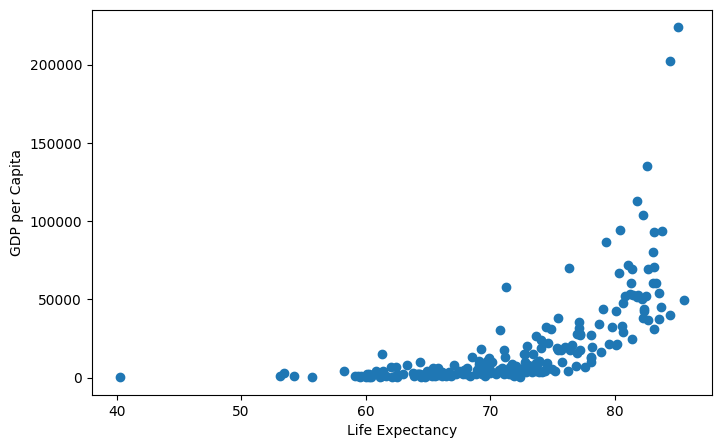

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df["Life expectancy at Birth"],
    df["GDP per Capita(US$)"]
)

plt.xlabel("Life Expectancy")
plt.ylabel("GDP per Capita")

plt.show()

The relationship between raw GDP and life expectancy appeared nonlinear.

In [26]:
import numpy as np

df["log_gdp"] = np.log(df["GDP per Capita(US$)"])

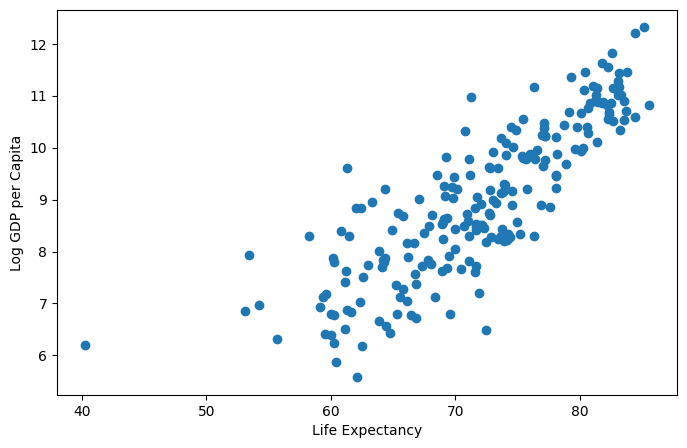

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Life expectancy at Birth"],
    df["log_gdp"]
)

plt.xlabel("Life Expectancy")
plt.ylabel("Log GDP per Capita")

plt.show()

A log transformation was applied to reduce skewness and improve linear interpretability. After applying a logarithmic transformation to GDP, the relationship became substantially more linear.

In [28]:
corr = df.corr(numeric_only=True)

print(
    corr["log_gdp"]
    .sort_values(ascending=False)
)

log_gdp                              1.000000
Life expectancy at Birth             0.839101
Individuals using the Internet(%)    0.795363
GDP per Capita(US$)                  0.769706
Urban Population(%)                  0.630016
Trade(as % of GDP)                   0.377412
Population Density                   0.226970
Unemployment Rate                   -0.087264
Inflation Rate                      -0.169274
Population Growth                   -0.523098
Name: log_gdp, dtype: float64


Linear regression was first used as a baseline model.

A Random Forest regressor was then tested to capture possible nonlinear
relationships between development indicators and GDP.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

features = [
    "Life expectancy at Birth",
    "Individuals using the Internet(%)",
    "Urban Population(%)",
    "Trade(as % of GDP)",
    "Population Density",
    "Unemployment Rate",
    "Inflation Rate",
    "Population Growth"
]

X = df[features]
y = df["log_gdp"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
from sklearn.metrics import r2_score

preds = model.predict(X_test)

print("R²:", r2_score(y_test, preds))

R²: 0.7038268457468596


In [31]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coeffs.sort_values(by="Coefficient", ascending=False))

                             Feature  Coefficient
0           Life expectancy at Birth     0.094109
1  Individuals using the Internet(%)     0.016616
2                Urban Population(%)     0.010119
3                 Trade(as % of GDP)     0.002119
4                 Population Density    -0.000018
6                     Inflation Rate    -0.003766
5                  Unemployment Rate    -0.011311
7                  Population Growth    -0.038604


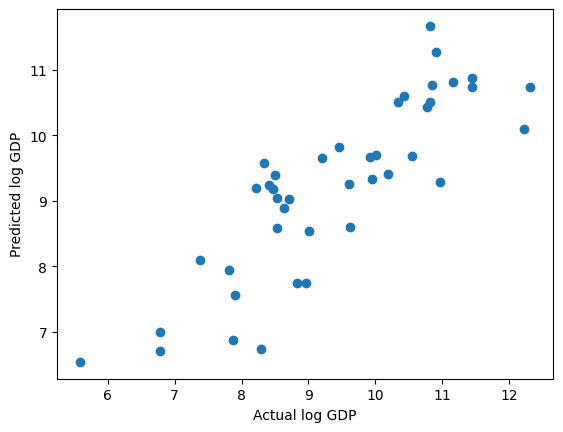

In [32]:
plt.scatter(y_test, preds)

plt.xlabel("Actual log GDP")
plt.ylabel("Predicted log GDP")

plt.show()

In [33]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

print(
    importance.sort_values(
        by="Importance",
        ascending=False
    )
)

                             Feature  Importance
0           Life expectancy at Birth    0.431570
1  Individuals using the Internet(%)    0.166921
2                Urban Population(%)    0.032770
5                  Unemployment Rate    0.006680
6                     Inflation Rate    0.004326
7                  Population Growth    0.002815
3                 Trade(as % of GDP)   -0.004642
4                 Population Density   -0.007696


In [34]:
features2 = ["Life expectancy at Birth", "Individuals using the Internet(%)", "Urban Population(%)"]


In [35]:
X = df[features2]
y = df["log_gdp"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
from sklearn.metrics import r2_score

preds = model.predict(X_test)

print("R²:", r2_score(y_test, preds))

R²: 0.7182730250260201


In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



In [38]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("R²:", r2_score(y_test, rf_preds))
print("MAE:", mean_absolute_error(y_test, rf_preds))


R²: 0.758988111241679
MAE: 0.5759465492796624


In [39]:
models = {"Linear Regression": preds, "Random Forest": rf_preds}

for name, p in models.items():

    print(f"\n{name}")

    print("R²:", round(r2_score(y_test,p),3))

    print("MAE:", round(
        mean_absolute_error(y_test,p),
        3
    ))

    print("RMSE:", round(
        mean_squared_error(
            y_test,
            p
        )**0.5,
        3
    ))


Linear Regression
R²: 0.718
MAE: 0.656
RMSE: 0.797

Random Forest
R²: 0.759
MAE: 0.576
RMSE: 0.737


Random Forest outperformed Linear Regression across all evaluation metrics, suggesting that the relationship between development indicators and GDP per capita contains nonlinear structure.

In [40]:
results = pd.DataFrame({

    "Country":
    df.loc[y_test.index,"Country Name"],

    "Actual":
    y_test,

    "Predicted":
    rf_preds
})

results["Residual"] = (
    results["Actual"]
    -
    results["Predicted"]
)

In [41]:
print(results.sort_values("Residual", ascending=False).head(10))

              Country     Actual  Predicted  Residual
77          Greenland  10.970540   8.891745  2.078795
9               Aruba  10.194265   8.512001  1.682264
152  Papua New Guinea   7.866177   6.394704  1.471473
114     Liechtenstein  12.215750  11.137508  1.078242
137             Nauru   9.614411   8.549727  1.064684
130            Monaco  12.318612  11.266370  1.052243
25           Botswana   8.962890   8.082919  0.879971
177      South Africa   8.828898   8.058240  0.770658
109            Latvia   9.916497   9.166929  0.749568
79               Guam  10.547310   9.840413  0.706897


In [42]:
print(results.sort_values("Residual").head(10))

                Country     Actual  Predicted  Residual
99               Jordan   8.338903   9.479241 -1.140338
31              Burundi   5.579656   6.532960 -0.953304
213  West Bank and Gaza   8.210297   9.047894 -0.837597
167             Senegal   7.376575   8.143881 -0.767306
46           Costa Rica   9.460174  10.123711 -0.663537
179               Spain  10.335253  10.845072 -0.509819
198             Turkiye   9.208515   9.717489 -0.508974
131            Mongolia   8.415740   8.871950 -0.456210
97              Jamaica   8.635097   8.979776 -0.344680
88              Iceland  11.162309  11.370952 -0.208643


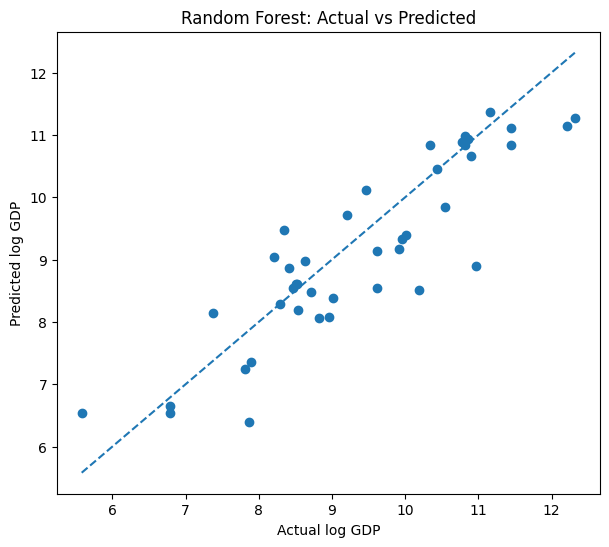

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(y_test, rf_preds)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--')

plt.xlabel("Actual log GDP")
plt.ylabel("Predicted log GDP")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

Largest prediction errors occurred among microstates, tourism-dependent economies, and politically constrained territories.
This suggests that standard development indicators do not fully capture all sources of economic variation.

Key findings:
- Life expectancy and internet access emerged as the strongest predictors.
- Log-transforming GDP substantially strengthened linear relationships.
- Random Forest achieved the stronger predictive performance (R² = 0.759).
- Largest prediction errors occured among microstates(Monaco, Liechtenstein), tourism dependant economies(Aruba), and politically constrained territories(Gaza). 